# 02 · Les cartes de caractéristiques (feature maps)

Dans le notebook 01, on a vu que les méthodes classiques ne regardent que la luminosité ou la couleur. Un réseau de neurones, lui, arrive à reconnaître un chien. Mais que voit-il vraiment quand il regarde une image ?

Tout repose sur une idée simple. Un **noyau** (ou filtre) est une petite grille de nombres. Quand on le fait glisser sur une image, il produit une **carte de caractéristiques**. Et chaque noyau fait ressortir un motif différent : bords verticaux, bords horizontaux, couleurs, textures.

On va vérifier ça pas à pas :
1. Une image, ce n'est que des nombres
2. La convolution à la main, sur une image minuscule
3. Des noyaux sur une vraie photo
4. Pourquoi un noyau est un détecteur de motif
5. Les images en couleur
6. Plusieurs noyaux = une couche de convolution (`Conv2d`)
7. Stride, padding et activation
8. Les noyaux appris par un vrai réseau (YOLO)
9. Ce qui se passe en profondeur dans le réseau

**Prérequis :** le notebook 01. Pas besoin de connaître le deep learning, il suffit de savoir multiplier et additionner.

## 0. Préparation

Les imports, et une petite fonction `afficher()` pour montrer plusieurs images côte à côte.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams["figure.dpi"] = 100


def afficher(images, titres=None, cmap="gray", taille=3.2, colorbar=False):
    # Affiche une liste d'images côte à côte
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(taille * n, taille))
    axes = np.atleast_1d(axes)
    for i, (ax, im) in enumerate(zip(axes, images)):
        h = ax.imshow(im, cmap=cmap)
        if titres:
            ax.set_title(titres[i], fontsize=10)
        ax.axis("off")
        if colorbar:
            fig.colorbar(h, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

## 1. Une image, ce n'est que des nombres

Pour un ordinateur, une image est un tableau de nombres :
- en niveaux de gris, un nombre par pixel, de 0 (noir) à 255 (blanc) ;
- en couleur, trois nombres par pixel (rouge, vert, bleu).

Image couleur : (148, 270, 3) -> (hauteur, largeur, 3 canaux)
Image en gris : (148, 270) -> (hauteur, largeur)


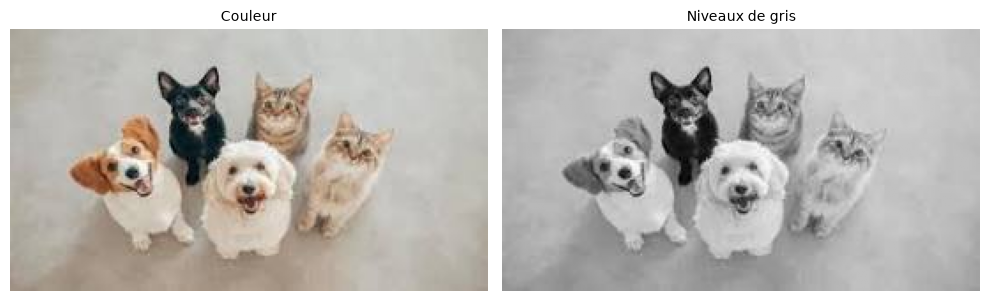

In [2]:
img_bgr = cv2.imread("../../img/dog_cat.png")              # OpenCV lit en BGR (Bleu, Vert, Rouge)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # matplotlib attend du RGB
gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Image couleur :", img_rgb.shape, "-> (hauteur, largeur, 3 canaux)")
print("Image en gris :", gris.shape, "-> (hauteur, largeur)")

afficher([img_rgb, gris], ["Couleur", "Niveaux de gris"], taille=5)

On zoome sur un carré de 8×8 pixels pour voir les nombres derrière l'image. On prend un endroit où l'oreille du chien noir se détache sur le fond clair.

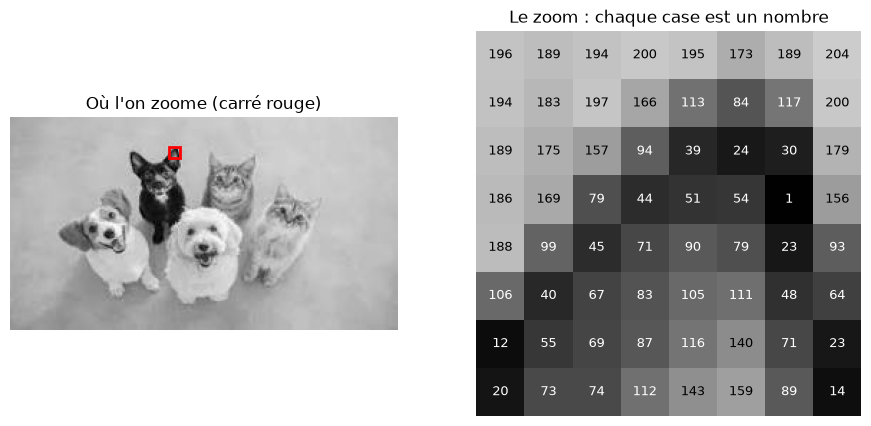

In [3]:
y, x = 20, 110   # coin haut-gauche du carré (ligne, colonne)
patch = gris[y:y + 8, x:x + 8]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(gris, cmap="gray")
axes[0].add_patch(plt.Rectangle((x, y), 8, 8, edgecolor="red", facecolor="none", lw=2))
axes[0].set_title("Où l'on zoome (carré rouge)")
axes[0].axis("off")

axes[1].imshow(patch, cmap="gray", vmin=0, vmax=255)
for (i, j), v in np.ndenumerate(patch):
    axes[1].text(j, i, v, ha="center", va="center", fontsize=9,
                 color="white" if v < 128 else "black")
axes[1].set_title("Le zoom : chaque case est un nombre")
axes[1].axis("off")
plt.show()

Tout ce qu'on fera ensuite, ce sont des calculs sur ces nombres.

## 2. La convolution à la main

### 2.1 Une image minuscule

On fabrique une image de 6×6 pixels : la moitié gauche est sombre (0), la moitié droite est claire (10). Il y a donc un bord vertical au milieu.

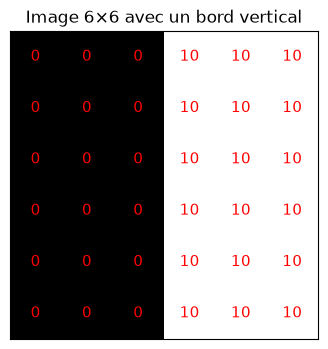

In [4]:
mini = np.array([
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
], dtype=np.float32)


def afficher_grille(ax, M, titre, cmap="gray"):
    # Affiche une matrice avec ses valeurs écrites dans chaque case
    lim = np.abs(M).max() or 1
    if cmap == "bwr":
        ax.imshow(M, cmap=cmap, vmin=-lim, vmax=lim)
    else:
        ax.imshow(M, cmap=cmap)
    for (i, j), v in np.ndenumerate(M):
        ax.text(j, i, f"{v:g}", ha="center", va="center", fontsize=11,
                color="red" if cmap == "gray" else "black")
    ax.set_title(titre)
    ax.set_xticks([]); ax.set_yticks([])


fig, ax = plt.subplots(figsize=(4, 4))
afficher_grille(ax, mini, "Image 6×6 avec un bord vertical")
plt.show()

### 2.2 Le noyau

Voici un noyau 3×3 très connu, le filtre de Sobel horizontal (Sobel X) :

$$
K = \begin{pmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{pmatrix}
$$

La colonne de gauche est négative, donc on retire les pixels de gauche. La colonne de droite est positive, donc on ajoute ceux de droite. La colonne du milieu vaut 0, on l'ignore.

Autrement dit, ce noyau calcule « droite moins gauche ».

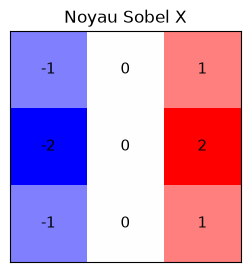

In [5]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float32)

fig, ax = plt.subplots(figsize=(3, 3))
afficher_grille(ax, sobel_x, "Noyau Sobel X", cmap="bwr")
plt.show()

### 2.3 Un seul calcul, pas à pas

Une convolution, c'est trois gestes :
1. on pose le noyau sur un morceau 3×3 de l'image ;
2. on multiplie chaque case du noyau par la case de l'image en dessous ;
3. on additionne les 9 résultats.

On obtient un seul nombre, qui devient un pixel de la carte de sortie. On essaie à deux endroits : en plein dans la zone sombre, puis sur le bord.

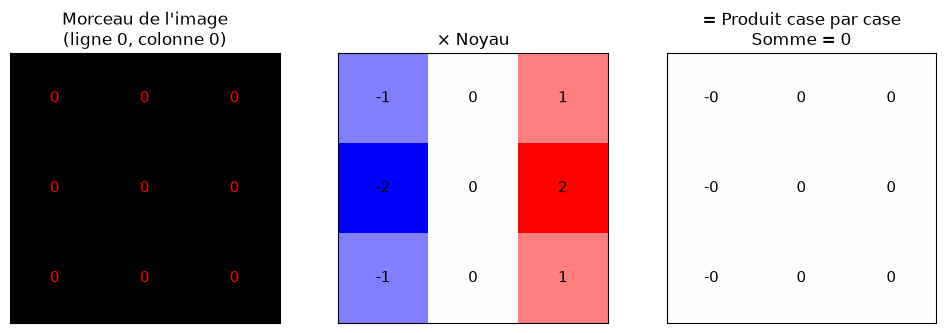

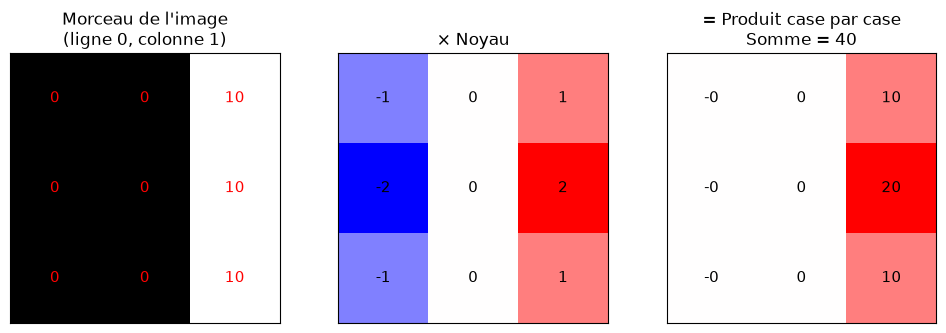

np.float32(40.0)

In [6]:
def un_calcul(image, noyau, ligne, col):
    morceau = image[ligne:ligne + 3, col:col + 3]
    produit = morceau * noyau
    somme = produit.sum()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
    afficher_grille(axes[0], morceau, f"Morceau de l'image\n(ligne {ligne}, colonne {col})")
    afficher_grille(axes[1], noyau, "× Noyau", cmap="bwr")
    afficher_grille(axes[2], produit, f"= Produit case par case\nSomme = {somme:g}", cmap="bwr")
    plt.tight_layout()
    plt.show()
    return somme


un_calcul(mini, sobel_x, ligne=0, col=0)   # zone uniforme
un_calcul(mini, sobel_x, ligne=0, col=1)   # à cheval sur le bord

Dans la zone uniforme, la gauche est égale à la droite, la somme vaut 0 : le noyau ne voit rien. Sur le bord, la droite est plus claire que la gauche, la somme vaut 40 : le noyau réagit fort.

### 2.4 Faire glisser le noyau partout

On répète ce calcul à chaque position de l'image, de gauche à droite et de haut en bas. La fonction ci-dessous le fait avec deux boucles `for`. C'est toute la convolution, il n'y a rien de plus.

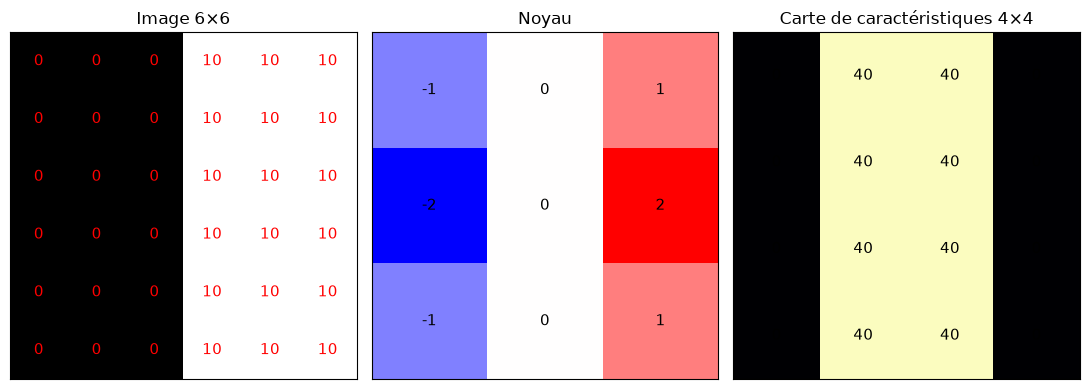

In [7]:
def convolution(image, noyau):
    # Convolution 2D faite à la main (sans padding, pas de 1)
    kh, kw = noyau.shape
    H, W = image.shape
    sortie = np.zeros((H - kh + 1, W - kw + 1), dtype=np.float32)
    for i in range(sortie.shape[0]):          # pour chaque ligne
        for j in range(sortie.shape[1]):      # pour chaque colonne
            morceau = image[i:i + kh, j:j + kw]
            sortie[i, j] = (morceau * noyau).sum()
    return sortie


carte = convolution(mini, sobel_x)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
afficher_grille(axes[0], mini, "Image 6×6")
afficher_grille(axes[1], sobel_x, "Noyau", cmap="bwr")
afficher_grille(axes[2], carte, "Carte de caractéristiques 4×4", cmap="magma")
plt.tight_layout()
plt.show()

On a notre première carte de caractéristiques. Elle vaut 40 exactement là où se trouve le bord vertical, et 0 partout ailleurs. Sobel X est donc un détecteur de bords verticaux.

Pourquoi la sortie fait 4×4 et pas 6×6 ? Le noyau 3×3 ne peut pas dépasser de l'image, il n'y a donc que 4 positions possibles par ligne (6 − 3 + 1 = 4). Le *padding*, qu'on verra plus loin, règle ce problème.

Que se passe-t-il si on tourne l'image d'un quart de tour, pour que le bord devienne horizontal ?

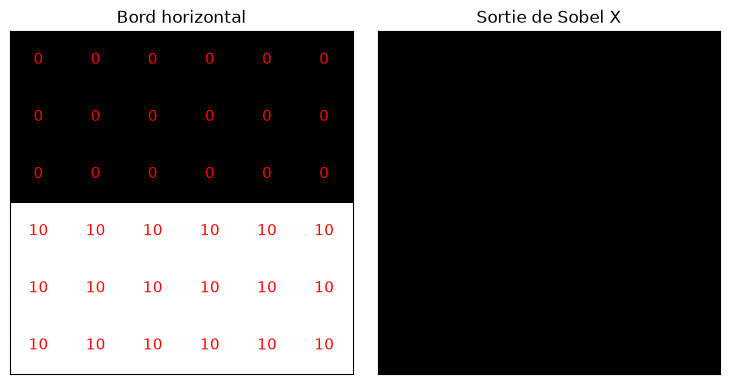

In [8]:
mini_horizontal = mini.T   # transposée : le bord vertical devient horizontal

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))
afficher_grille(axes[0], mini_horizontal, "Bord horizontal")
afficher_grille(axes[1], convolution(mini_horizontal, sobel_x), "Sortie de Sobel X", cmap="magma")
plt.tight_layout()
plt.show()

La carte est entièrement nulle : Sobel X ne voit pas les bords horizontaux. Pour les voir, il faut un autre noyau. C'est l'idée de départ : un noyau, un type de motif.

## 3. Des noyaux sur une vraie photo

On applique maintenant notre fonction `convolution` à la photo en niveaux de gris, et on compare avec `cv2.filter2D` d'OpenCV, qui fait le même calcul en beaucoup plus rapide.

Notre fonction : 0.195 s
OpenCV         : 0.0359 s
Mêmes résultats ? True


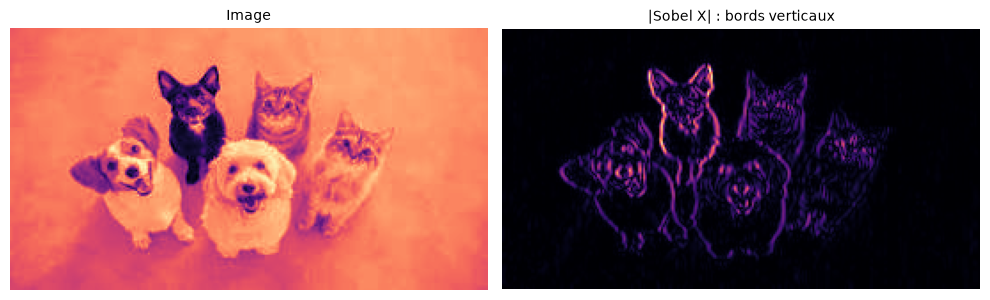

In [9]:
import time

g = gris.astype(np.float32) / 255.0   # on ramène les pixels entre 0 et 1

t0 = time.time()
carte_main = convolution(g, sobel_x)
t1 = time.time()
carte_cv = cv2.filter2D(g, cv2.CV_32F, sobel_x)[1:-1, 1:-1]   # on retire les bords pour avoir la même taille
t2 = time.time()

print(f"Notre fonction : {t1 - t0:.3f} s")
print(f"OpenCV         : {t2 - t1:.4f} s")
print("Mêmes résultats ?", np.allclose(carte_main, carte_cv, atol=1e-5))

afficher([g, np.abs(carte_main)], ["Image", "|Sobel X| : bords verticaux"], cmap="magma", taille=5)

Les deux résultats sont identiques. OpenCV et PyTorch font exactement ce calcul, simplement en plus optimisé.

On affiche la valeur absolue parce qu'un bord « sombre → clair » donne un nombre positif, et un bord « clair → sombre » un nombre négatif. Dans les deux cas, c'est un bord.

### 3.1 Plusieurs noyaux classiques

Pour chaque noyau, regarde d'abord ses nombres, puis ce qui s'allume dans la carte.

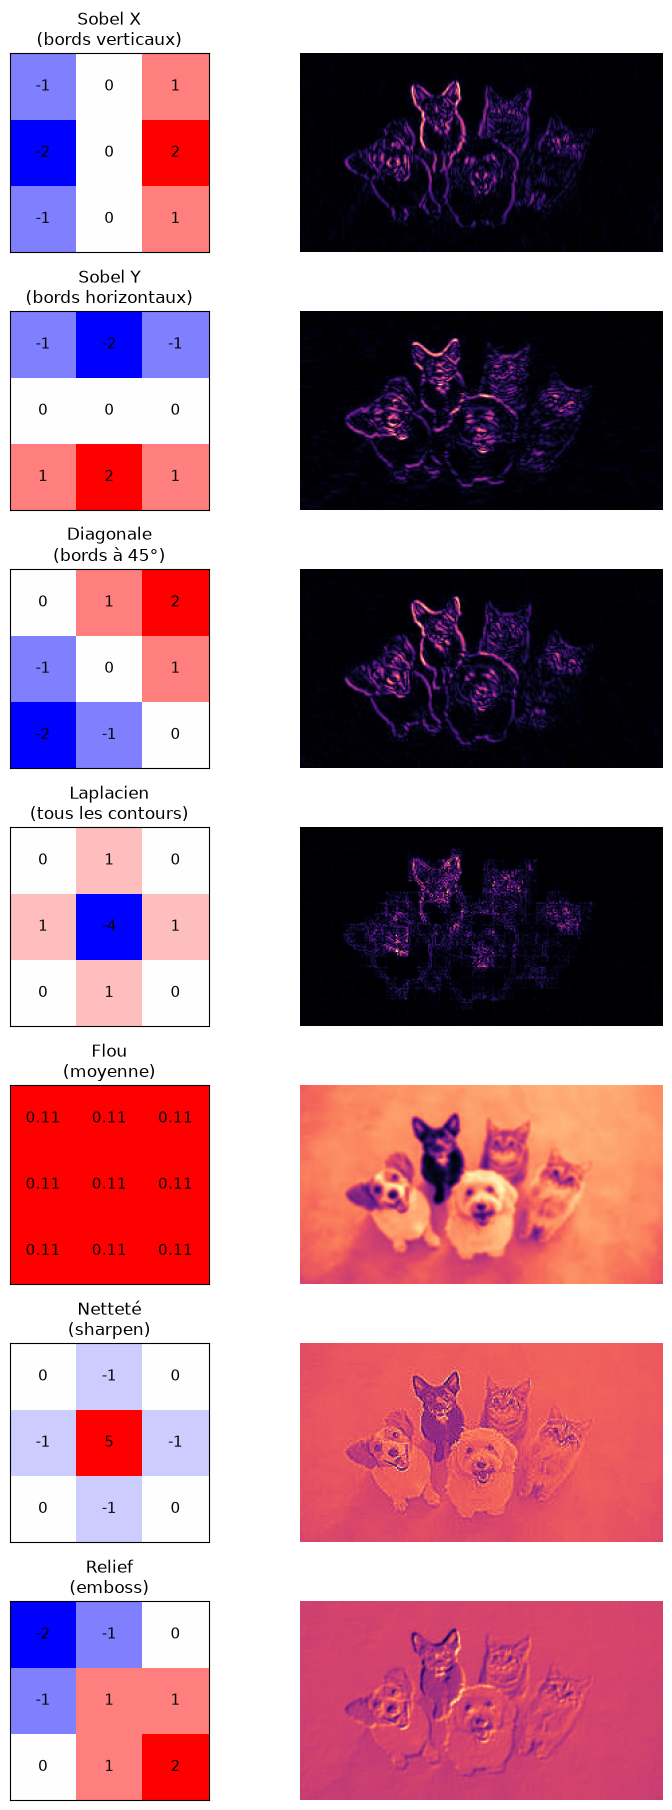

In [10]:
NOYAUX = {
    "Sobel X\n(bords verticaux)":       np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Sobel Y\n(bords horizontaux)":     np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    "Diagonale\n(bords à 45°)":         np.array([[0, 1, 2], [-1, 0, 1], [-2, -1, 0]]),
    "Laplacien\n(tous les contours)":   np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    "Flou\n(moyenne)":                  np.ones((3, 3)) / 9,
    "Netteté\n(sharpen)":               np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    "Relief\n(emboss)":                 np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
}

fig, axes = plt.subplots(len(NOYAUX), 2, figsize=(8, 2.6 * len(NOYAUX)),
                         gridspec_kw={"width_ratios": [1, 2.2]})
for ligne, (nom, k) in enumerate(NOYAUX.items()):
    k = k.astype(np.float32)
    afficher_grille(axes[ligne, 0], np.round(k, 2), nom, cmap="bwr")
    carte = cv2.filter2D(g, cv2.CV_32F, k)
    # Noyaux de somme nulle = détecteurs : on affiche |carte|. Sinon : l'image filtrée.
    axes[ligne, 1].imshow(np.abs(carte) if abs(k.sum()) < 1e-6 else carte, cmap="magma")
    axes[ligne, 1].axis("off")
plt.tight_layout()
plt.show()

### Comment lire ces résultats

| Noyau | Ce qu'il calcule | Ce qui s'allume |
|---|---|---|
| Sobel X | droite − gauche | les contours verticaux (pattes, côtés des têtes) |
| Sobel Y | bas − haut | les contours horizontaux (menton, haut des têtes) |
| Diagonale | haut-droite − bas-gauche | les contours en biais |
| Laplacien | le centre comparé à ses voisins | tous les contours fins, quelle que soit la direction |
| Flou | la moyenne des 9 voisins | rien de particulier, l'image est lissée |
| Netteté | le centre renforcé, les voisins retirés | une image plus contrastée |
| Relief | un côté − le côté opposé | un effet 3D, comme une gravure |

Une règle simple : quand les valeurs d'un noyau s'additionnent à 0 (Sobel, Laplacien…), c'est un détecteur. Il donne 0 sur les zones unies et ne réagit qu'aux changements.

## 4. Pourquoi un noyau est un détecteur de motif

La somme des produits est la plus grande quand le morceau d'image ressemble au noyau : les pixels clairs tombent sur les poids positifs, les pixels sombres sur les poids négatifs.

Pour le vérifier, on cherche l'endroit où la carte Sobel X est la plus forte, et on regarde le morceau d'image à cet endroit.

Réponse maximale = 2.93 à la position (ligne=23, colonne=117)


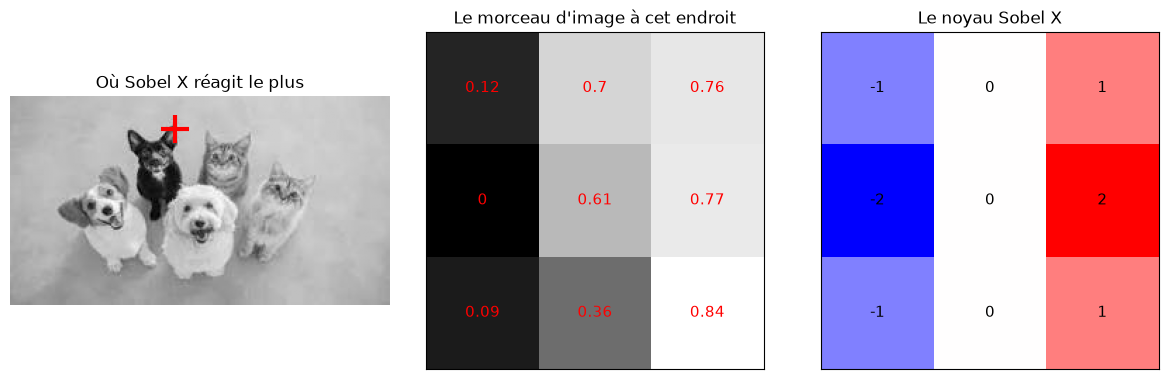

In [11]:
carte = cv2.filter2D(g, cv2.CV_32F, sobel_x)
i, j = np.unravel_index(np.argmax(carte), carte.shape)   # position de la valeur maximale
morceau = g[i - 1:i + 2, j - 1:j + 2]

print(f"Réponse maximale = {carte[i, j]:.2f} à la position (ligne={i}, colonne={j})")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(g, cmap="gray")
axes[0].plot(j, i, "r+", markersize=20, mew=3)
axes[0].set_title("Où Sobel X réagit le plus")
axes[0].axis("off")
afficher_grille(axes[1], np.round(morceau, 2), "Le morceau d'image à cet endroit")
afficher_grille(axes[2], sobel_x, "Le noyau Sobel X", cmap="bwr")
plt.tight_layout()
plt.show()

Le morceau est sombre à gauche et clair à droite. Il a la même forme que le noyau, négatif à gauche et positif à droite.

En chaque point, la carte répond donc à la question : « est-ce qu'ici, l'image ressemble à mon noyau ? » C'est pour ça qu'on parle de carte de *caractéristiques* : elle indique où se trouve un motif précis dans l'image.

## 5. Et les images en couleur ?

Une image couleur a 3 canaux (R, V, B). Un noyau pour la couleur a donc 3 couches : c'est un cube 3×3×3.

Le calcul ne change pas. Chaque couche du noyau est appliquée à son canal (R avec R, V avec V, B avec B), puis on additionne les 3 résultats. On obtient une seule carte.

On fabrique un noyau qui détecte le roux et l'orange : +1 sur le rouge, −0,5 sur le vert, −1 sur le bleu.

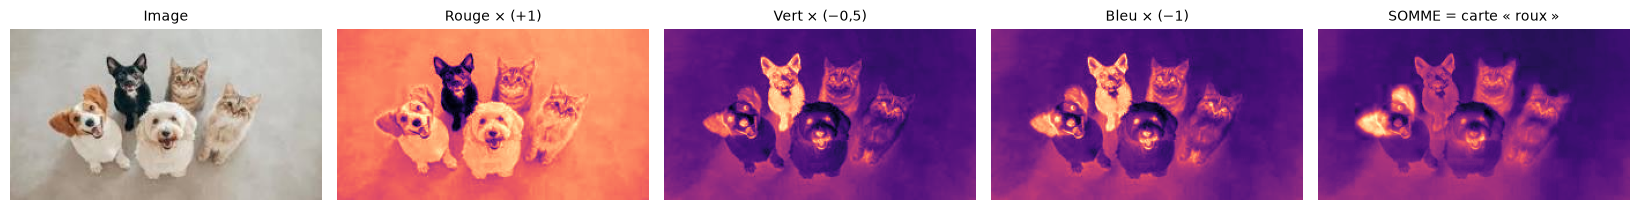

In [12]:
rgb = img_rgb.astype(np.float32) / 255.0

# Noyau 3×3×3 : une grille 3×3 par canal. On ne met un poids qu'au centre.
noyau_roux = np.zeros((3, 3, 3), dtype=np.float32)
noyau_roux[1, 1, 0] = 1.0     # canal Rouge : on ajoute
noyau_roux[1, 1, 1] = -0.5    # canal Vert  : on retire un peu
noyau_roux[1, 1, 2] = -1.0    # canal Bleu  : on retire

# Étape 1 : un calcul par canal
cartes_par_canal = [cv2.filter2D(rgb[:, :, c], cv2.CV_32F, noyau_roux[:, :, c]) for c in range(3)]
# Étape 2 : on additionne les 3 cartes
carte_roux = sum(cartes_par_canal)

afficher([rgb, *cartes_par_canal, carte_roux],
         ["Image", "Rouge × (+1)", "Vert × (−0,5)", "Bleu × (−1)", "SOMME = carte « roux »"],
         cmap="magma", taille=3.3)

Le chien roux à gauche et le chat tigré s'allument, le chien blanc et le chien noir restent sombres.

Un noyau peut donc détecter une forme (les bords), une couleur, ou les deux à la fois. On retrouvera ce genre de noyau dans YOLO.

## 6. Plusieurs noyaux = une couche de convolution

Dans un réseau de neurones, une couche de convolution (`nn.Conv2d` dans PyTorch) n'est rien d'autre qu'un paquet de noyaux. Chaque noyau produit sa carte, et on empile toutes les cartes. Une couche avec 4 noyaux produit 4 cartes : on dit que la sortie a 4 canaux.

Pour le montrer, on crée une couche `nn.Conv2d`, on y met nos propres noyaux (Sobel X, Sobel Y, Laplacien, Flou), et on regarde ce qui sort.

Forme des poids : (4, 1, 3, 3)
Entrée : (1, 1, 148, 270)  -> Sortie : (1, 4, 148, 270)


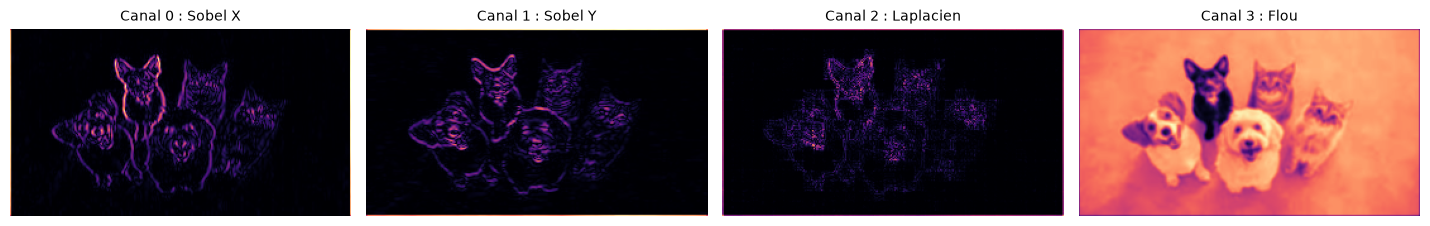

In [13]:
mes_noyaux = [
    np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),     # Sobel X
    np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),     # Sobel Y
    np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),       # Laplacien
    np.ones((3, 3)) / 9,                                # Flou
]

# 1 canal d'entrée (image en gris) -> 4 canaux de sortie (4 noyaux)
couche = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1, bias=False)

# Les poids d'une Conv2d ont la forme (nb_noyaux, nb_canaux_entrée, hauteur, largeur)
print("Forme des poids :", tuple(couche.weight.shape))

with torch.no_grad():
    couche.weight[:] = torch.tensor(np.stack(mes_noyaux)[:, None], dtype=torch.float32)

x = torch.tensor(g)[None, None]   # forme (lot=1, canaux=1, H, W)
with torch.no_grad():
    y = couche(x)

print("Entrée :", tuple(x.shape), " -> Sortie :", tuple(y.shape))
afficher([y[0, c].abs().numpy() for c in range(4)],
         ["Canal 0 : Sobel X", "Canal 1 : Sobel Y", "Canal 2 : Laplacien", "Canal 3 : Flou"],
         cmap="magma", taille=3.6)

C'est l'idée centrale de ce notebook :

$$
\text{1 couche Conv2d} = N \text{ noyaux} \;\longrightarrow\; N \text{ cartes de caractéristiques empilées}
$$

La seule différence avec un vrai réseau, c'est qu'ici on a choisi nous-mêmes les nombres des noyaux. Dans un réseau entraîné, ces nombres sont appris automatiquement, pour détecter ce qui est utile à la tâche, par exemple trouver des chiens et des chats.

## 7. Stride, padding et activation

### 7.1 Le padding

On ajoute une bordure de zéros autour de l'image pour que le noyau puisse aussi se poser sur les bords. Avec `padding=1` et un noyau 3×3, la sortie garde la même taille que l'entrée.

### 7.2 Le stride

C'est le nombre de pixels dont on décale le noyau à chaque fois. Avec `stride=2`, on saute un pixel sur deux, et la sortie est 2 fois plus petite en hauteur et en largeur.

La taille de sortie se calcule avec cette formule :

$$
\text{sortie} = \left\lfloor \frac{\text{entrée} + 2 \times \text{padding} - \text{taille du noyau}}{\text{stride}} \right\rfloor + 1
$$

In [14]:
H, W = g.shape
print(f"Image d'entrée : {H} × {W}\n")

for padding, stride in [(0, 1), (1, 1), (1, 2), (1, 4)]:
    c = nn.Conv2d(1, 1, kernel_size=3, padding=padding, stride=stride)
    sortie = c(x).shape[-2:]
    formule = ((H + 2 * padding - 3) // stride + 1, (W + 2 * padding - 3) // stride + 1)
    print(f"padding={padding}, stride={stride}  ->  sortie {tuple(sortie)}   (formule : {formule})")

Image d'entrée : 148 × 270

padding=0, stride=1  ->  sortie (146, 268)   (formule : (146, 268))
padding=1, stride=1  ->  sortie (148, 270)   (formule : (148, 270))
padding=1, stride=2  ->  sortie (74, 135)   (formule : (74, 135))
padding=1, stride=4  ->  sortie (37, 68)   (formule : (37, 68))


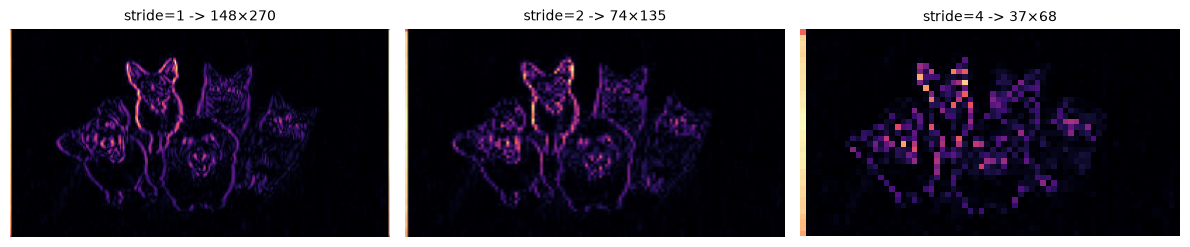

In [15]:
cartes_stride = []
for s in [1, 2, 4]:
    with torch.no_grad():
        out = F.conv2d(x, couche.weight[:1], stride=s, padding=1)
    cartes_stride.append(out[0, 0].abs().numpy())

afficher(cartes_stride,
         [f"stride={s} -> {m.shape[0]}×{m.shape[1]}" for s, m in zip([1, 2, 4], cartes_stride)],
         cmap="magma", taille=4)

Plus le stride est grand, plus la carte est petite et grossière. On perd du détail, mais les calculs suivants vont beaucoup plus vite, et chaque pixel de la carte résume une zone plus grande de l'image (on y revient dans la partie 9).

### 7.3 L'activation

Après chaque convolution, un réseau applique une fonction d'activation. La plus simple est ReLU, qui garde les valeurs positives et met les négatives à zéro :

$$\text{ReLU}(v) = \max(0, v)$$

Elle ne garde que les endroits où le noyau a vraiment trouvé son motif. YOLO utilise SiLU, une version plus douce, mais l'idée est la même.

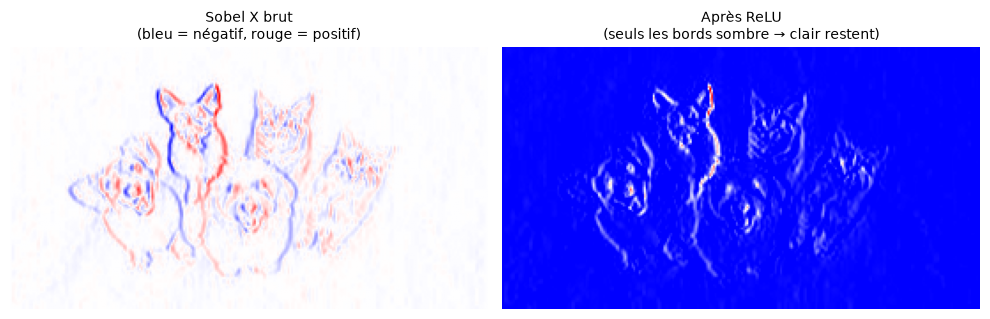

In [16]:
brut = cv2.filter2D(g, cv2.CV_32F, sobel_x)
relu = np.maximum(0, brut)

afficher([brut, relu],
         ["Sobel X brut\n(bleu = négatif, rouge = positif)", "Après ReLU\n(seuls les bords sombre → clair restent)"],
         cmap="bwr", taille=5)

## 8. Les noyaux appris par un vrai réseau : YOLO

On passe à un vrai réseau, YOLO (`yolo26n-seg.pt`), un modèle de segmentation déjà entraîné. Personne ne lui a donné ses noyaux : il les a appris en voyant des milliers d'images.

La question : est-ce qu'il a appris des choses qui ressemblent à nos noyaux faits à la main ?

In [17]:
from ultralytics import YOLO

modele = YOLO("../../models/yolo26n-seg.pt").model.float().eval()

# Les 12 premiers blocs du réseau (la partie qui extrait les caractéristiques)
for i, bloc in enumerate(modele.model[:11]):
    print(i, type(bloc).__name__)

0 Conv
1 Conv
2 C3k2
3 Conv
4 C3k2
5 Conv
6 C3k2
7 Conv
8 C3k2
9 SPPF
10 C2PSA


Le tout premier bloc est une convolution. Regardons ce qu'il contient.

In [18]:
conv0 = modele.model[0].conv
print(conv0)
print("Forme des poids :", tuple(conv0.weight.shape), "-> 16 noyaux de taille 3 canaux × 3 × 3")

Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
Forme des poids : (16, 3, 3, 3) -> 16 noyaux de taille 3 canaux × 3 × 3


16 noyaux, chacun de taille 3×3×3 (3×3 pixels sur 3 couleurs), comme notre détecteur de roux de la partie 5. Le `stride=(2, 2)` veut dire que la sortie sera 2 fois plus petite que l'image.

On prépare l'image comme YOLO l'attend (RGB, valeurs entre 0 et 1, taille multiple de 32), puis on affiche chaque noyau appris à côté de la carte qu'il produit.

Entrée du réseau : (1, 3, 352, 640)
Sortie : (16, 176, 320) -> 16 cartes


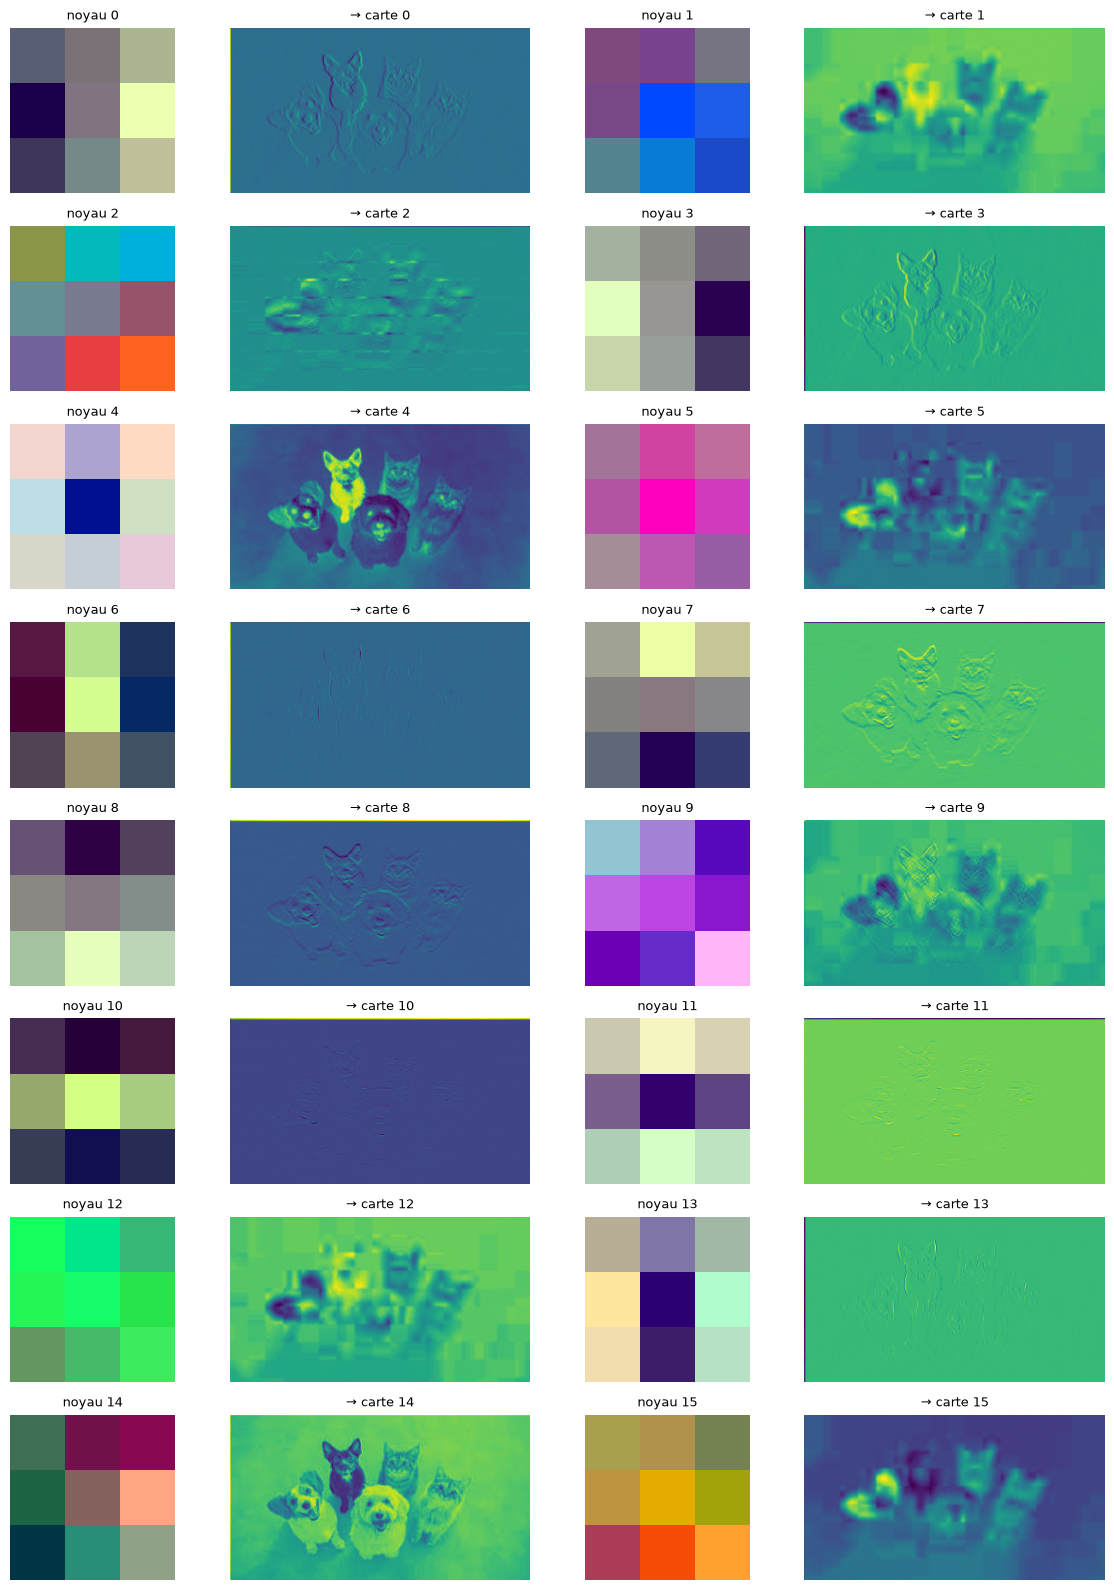

In [19]:
# Préparation de l'image pour YOLO
H0, W0 = img_rgb.shape[:2]
echelle = 640 / max(H0, W0)
h32 = int(round(H0 * echelle / 32)) * 32
w32 = int(round(W0 * echelle / 32)) * 32
entree = cv2.resize(img_rgb, (w32, h32)).astype(np.float32) / 255.0
entree = torch.from_numpy(entree).permute(2, 0, 1)[None]   # (1, 3, H, W)
print("Entrée du réseau :", tuple(entree.shape))

# On applique UNIQUEMENT les 16 noyaux de la première couche
poids = conv0.weight.detach()
with torch.no_grad():
    cartes0 = F.conv2d(entree, poids, stride=2, padding=1)[0]
print("Sortie :", tuple(cartes0.shape), "-> 16 cartes")

fig, axes = plt.subplots(8, 4, figsize=(12, 16))
for n in range(16):
    ligne, col = n // 2, (n % 2) * 2
    k = poids[n].permute(1, 2, 0).numpy()               # (3, 3, 3) en image couleur
    k = (k - k.min()) / (k.max() - k.min() + 1e-8)     # ramené entre 0 et 1 pour l'afficher
    axes[ligne, col].imshow(k, interpolation="nearest")
    axes[ligne, col].set_title(f"noyau {n}", fontsize=9)
    axes[ligne, col + 1].imshow(cartes0[n].numpy(), cmap="viridis")
    axes[ligne, col + 1].set_title(f"→ carte {n}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Ce qu'on observe

Personne n'a écrit ces noyaux, et pourtant :
- plusieurs cartes montrent les contours des animaux, avec une direction privilégiée. Ce sont des détecteurs de bords, comme Sobel : le réseau a retrouvé tout seul ce que les humains avaient inventé à la main ;
- d'autres réagissent à la couleur ou à la luminosité, le chien noir ou les chiens blancs ressortent nettement. Ce sont des cousins de notre détecteur de roux ;
- quelques cartes sont presque plates : ces noyaux cherchent un motif peu présent dans cette image.

Attention, les couleurs d'un noyau affiché ne sont pas exactement « la couleur qu'il voit ». On a étiré ses poids entre 0 et 1 pour pouvoir le dessiner. Un noyau très coloré mélange les canaux de façon inégale, il est sensible à la couleur. Un noyau gris traite les 3 canaux pareil, il est sensible à la forme.

Pour vérifier l'intuition « détecteur de bords », on calcule la ressemblance de chaque noyau appris avec Sobel X et Sobel Y.

In [20]:
def ressemblance(a, b):
    # Similarité cosinus : 1 = même forme, 0 = rien à voir, -1 = forme inversée
    a, b = a.flatten(), b.flatten()
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


sobel_y = sobel_x.T
print("noyau | ~Sobel X | ~Sobel Y")
for n in range(16):
    k_gris = poids[n].sum(0).numpy()   # on additionne les 3 canaux -> noyau 3×3 « en gris »
    sx, sy = ressemblance(k_gris, sobel_x), ressemblance(k_gris, sobel_y)
    marque = "  <- détecteur de bords" if max(abs(sx), abs(sy)) > 0.7 else ""
    print(f"  {n:2d}  |  {sx:+.2f}   |  {sy:+.2f}{marque}")

noyau | ~Sobel X | ~Sobel Y
   0  |  +0.99   |  +0.01  <- détecteur de bords
   1  |  +0.20   |  -0.01
   2  |  -0.26   |  -0.21
   3  |  -0.97   |  +0.04  <- détecteur de bords
   4  |  -0.01   |  +0.06
   5  |  +0.19   |  +0.07
   6  |  +0.03   |  -0.08
   7  |  +0.01   |  -0.98  <- détecteur de bords
   8  |  +0.01   |  +0.99  <- détecteur de bords
   9  |  -0.13   |  -0.14
  10  |  +0.04   |  +0.03
  11  |  -0.03   |  -0.02
  12  |  -0.17   |  +0.03
  13  |  -0.03   |  -0.12
  14  |  +0.73   |  +0.19  <- détecteur de bords
  15  |  -0.15   |  -0.19


Une ressemblance proche de +1 (ou de −1, c'est-à-dire le même motif inversé) confirme que certains noyaux appris sont presque des filtres de Sobel.

## 9. Ce qui se passe en profondeur dans le réseau

Un réseau empile des dizaines de couches. Le point important : la couche 2 n'applique pas ses noyaux sur l'image, mais sur les cartes produites par la couche 1. Elle combine donc des motifs déjà détectés :
- couche 1 : des bords ;
- couche 2 : des bords combinés, qui donnent des coins, des courbes, des textures ;
- couches suivantes : des combinaisons de combinaisons, qui donnent des yeux, des oreilles, du pelage ;
- tout au fond : des concepts comme « tête de chien » ou « chat ».

Pour voir les cartes à l'intérieur du réseau, on utilise des *hooks* : de petites fonctions que PyTorch appelle quand une couche produit sa sortie, et qui nous permettent d'en garder une copie.

In [21]:
COUCHES = [0, 1, 2, 4, 6, 8]
activations = {}


def creer_hook(numero):
    def hook(module, entree, sortie):
        activations[numero] = sortie.detach()[0]   # on garde la sortie de la couche
    return hook


crochets = [modele.model[i].register_forward_hook(creer_hook(i)) for i in COUCHES]
with torch.no_grad():
    modele(entree)          # un seul passage de l'image dans tout le réseau
for c in crochets:
    c.remove()              # on retire les crochets une fois fini

print("couche | type  | canaux | taille de chaque carte")
for i in COUCHES:
    a = activations[i]
    print(f"  {i:4d} | {type(modele.model[i]).__name__:5s} | {a.shape[0]:6d} | {a.shape[1]} × {a.shape[2]}")

couche | type  | canaux | taille de chaque carte
     0 | Conv  |     16 | 176 × 320
     1 | Conv  |     32 | 88 × 160
     2 | C3k2  |     64 | 88 × 160
     4 | C3k2  |    128 | 44 × 80
     6 | C3k2  |    128 | 22 × 40
     8 | C3k2  |    256 | 11 × 20


Dans ce tableau, la taille des cartes diminue (à cause des `stride=2`) et le nombre de canaux augmente : 16, 32, 64, 128, 256. Il faut plus de détecteurs pour représenter des motifs plus complexes, et on a besoin de moins de précision sur leur position.

On affiche, pour chaque couche, les 6 cartes les plus actives.

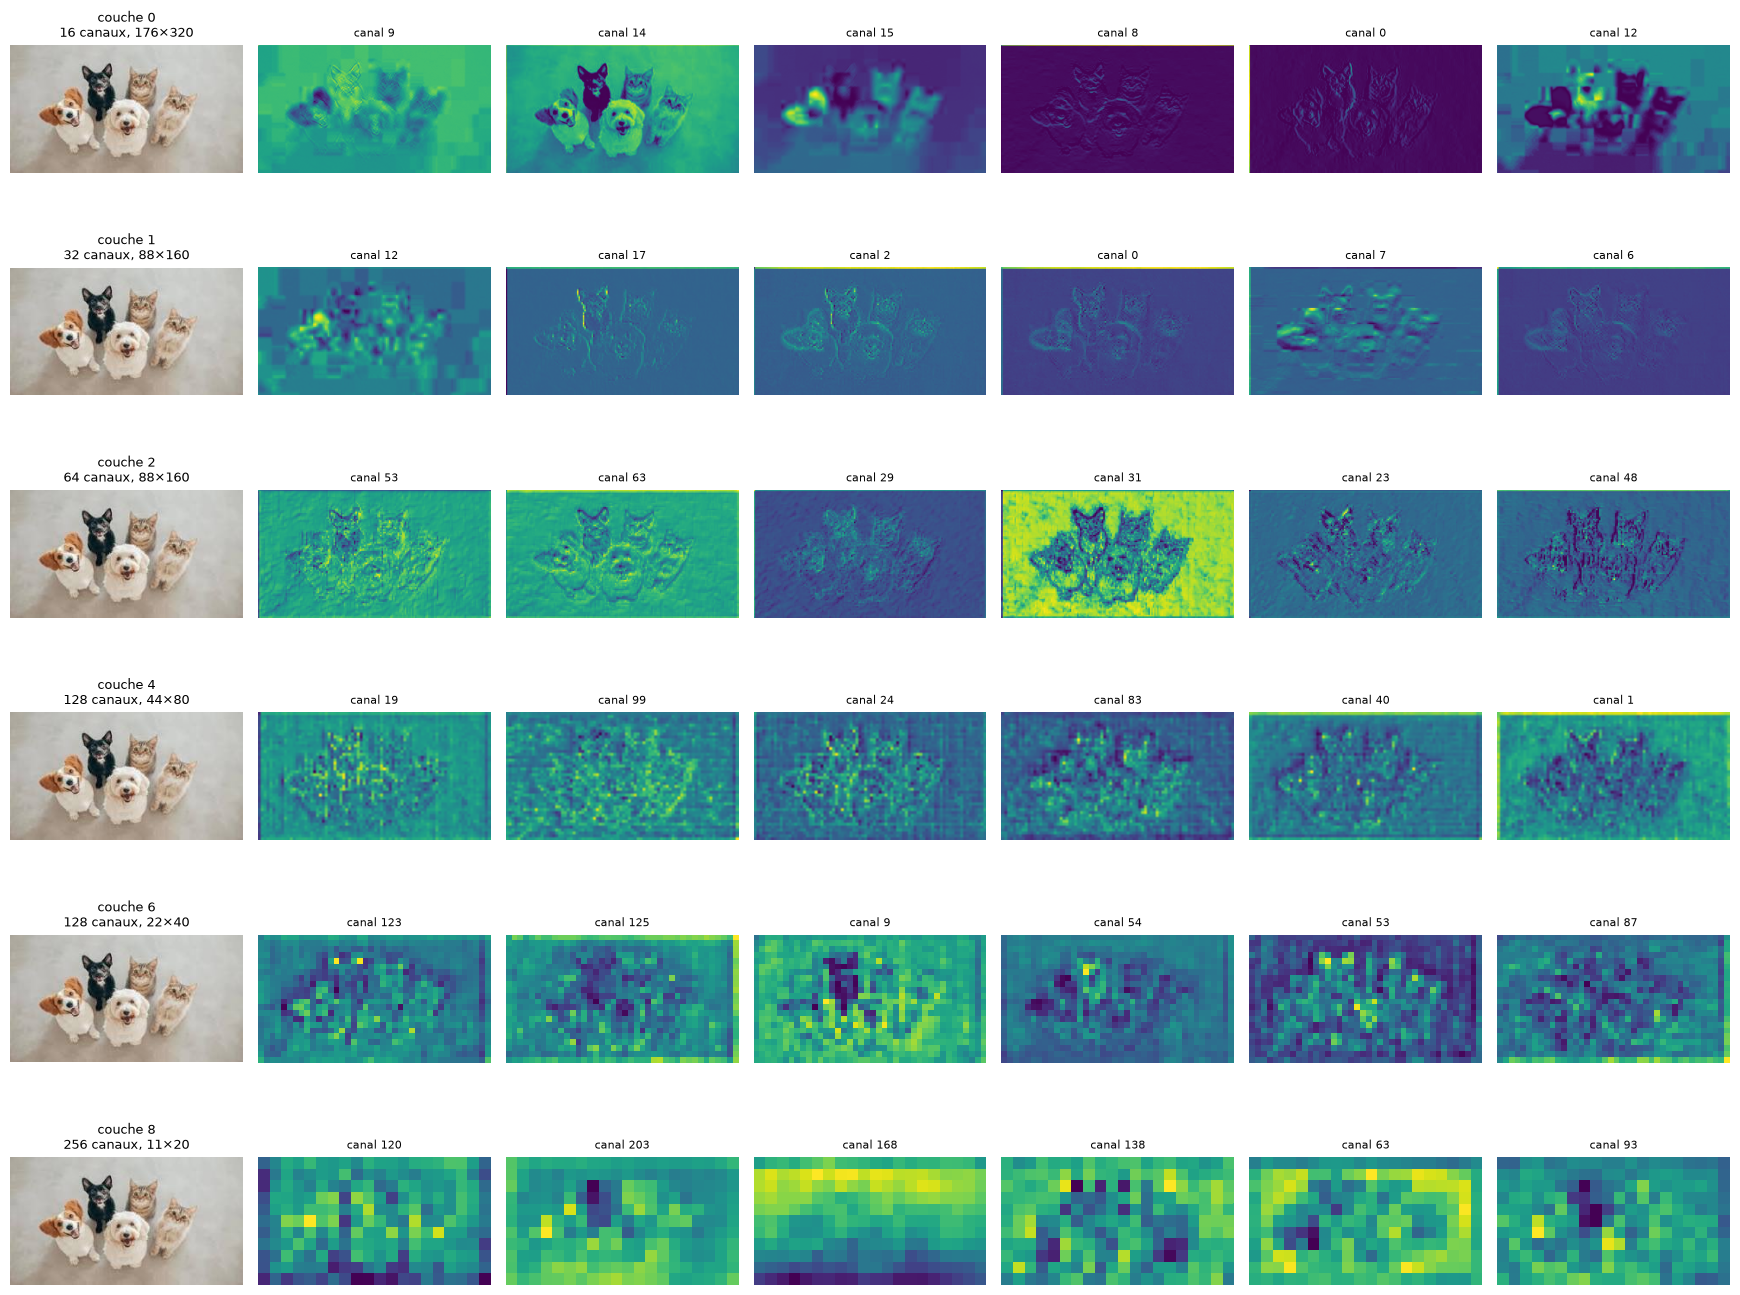

In [22]:
N = 6
fig, axes = plt.subplots(len(COUCHES), N + 1, figsize=(2.5 * (N + 1), 2.3 * len(COUCHES)))
for ligne, i in enumerate(COUCHES):
    a = activations[i]
    axes[ligne, 0].imshow(img_rgb)
    axes[ligne, 0].set_title(f"couche {i}\n{a.shape[0]} canaux, {a.shape[1]}×{a.shape[2]}", fontsize=9)
    plus_actifs = a.abs().mean(dim=(1, 2)).argsort(descending=True)[:N]
    for col, canal in enumerate(plus_actifs.tolist(), start=1):
        axes[ligne, col].imshow(a[canal].numpy(), cmap="viridis")
        axes[ligne, col].set_title(f"canal {canal}", fontsize=8)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Comment lire cette figure

| Profondeur | Ce qu'on voit | Ce que ça veut dire |
|---|---|---|
| Couches 0-1 | des contours nets, des zones de couleur | des motifs simples : bords, couleurs |
| Couche 2 | des textures, le fond séparé des animaux | des motifs locaux combinés |
| Couches 4-6 | des taches plus grossières sur les têtes, les yeux | des morceaux d'objets |
| Couche 8 | de grandes cases floues, difficiles à lire | des concepts abstraits que seul le réseau comprend |

Plus on descend, moins c'est lisible pour nous, mais plus c'est utile pour le réseau. Une case de la couche 8 ne dit plus « il y a un bord ici », plutôt « il y a quelque chose qui ressemble à une tête dans cette zone ».

### Le champ récepteur

Pourquoi les couches profondes voient-elles des choses plus grandes ? Un pixel de la couche 1 dépend d'un carré 3×3 de l'image. Un pixel de la couche 2 dépend de 3×3 pixels de la couche 1, qui dépendent chacun de 3×3 pixels de l'image, et ainsi de suite. La zone vue grandit à chaque couche, et encore plus vite avec les strides.

Cette zone s'appelle le champ récepteur. On peut la calculer :

In [23]:
# Pour une pile de convolutions 3×3 : champ = champ + (3 - 1) × (produit des strides précédents)
champ, saut = 1, 1
print("couche | stride | champ récepteur (en pixels de l'image)")
for numero, stride in enumerate([2, 2, 1, 2, 1, 2, 1, 2]):
    champ += (3 - 1) * saut
    saut *= stride
    print(f"  {numero + 1:4d} | {stride:6d} | {champ} × {champ}")

couche | stride | champ récepteur (en pixels de l'image)
     1 |      2 | 3 × 3
     2 |      2 | 7 × 7
     3 |      1 | 15 × 15
     4 |      2 | 23 × 23
     5 |      1 | 39 × 39
     6 |      2 | 55 × 55
     7 |      1 | 87 × 87
     8 |      2 | 119 × 119


C'est un calcul simplifié, avec une seule convolution 3×3 par étape. Les vrais blocs `C3k2` de YOLO en contiennent plusieurs, leur champ récepteur est donc encore plus grand.

Après quelques couches, un seul pixel voit une grande partie de l'image. C'est ce qui lui permet de reconnaître un objet entier.

## À retenir

- Une image est un tableau de nombres. Un noyau est une petite grille de nombres (3×3, ou 3×3×3 en couleur).
- La convolution, c'est faire glisser le noyau, multiplier case par case et additionner. Une position donne un pixel de sortie.
- La carte de caractéristiques dit, en chaque point, si l'image ressemble au noyau. Noyau différent, carte différente.
- Une couche `Conv2d`, c'est N noyaux qui donnent N cartes empilées (N canaux).
- Le stride réduit la taille, le padding garde les bords, l'activation (ReLU, SiLU) ne garde que les réponses positives.
- Dans un réseau entraîné, les noyaux sont appris. Les premiers ressemblent aux filtres classiques (bords, couleurs).
- Plus on descend, plus les couches combinent les cartes précédentes : les motifs deviennent complexes et abstraits, et le champ récepteur grandit.

## Exercices

1. Devine avant de lancer : quelle carte donne le noyau `[[1,1,1],[1,1,1],[1,1,1]]`, sans diviser par 9 ? Pourquoi l'image devient-elle presque blanche ?
2. Invente un noyau qui détecte les bords à −45° (l'autre diagonale). Indice : fais tourner le noyau « Diagonale ».
3. Modifie `noyau_roux` pour qu'il détecte le noir. Indice : des poids négatifs sur les 3 canaux. Quel animal s'allume ?
4. Refais la partie 8 avec `dog.png`. Les noyaux « couleur » réagissent-ils aux mêmes choses ?
5. Pour aller plus loin : dans la partie 9, prends une carte de la couche 8, agrandis-la à la taille de l'image (`cv2.resize`) et superpose-la à la photo (`alpha=0.5`). Quelle zone de l'image active ce canal ?

**Suite :** [03 · U-Net](03_unet.ipynb)